In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pickle

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
df = pd.read_csv(
    r'D:\projects\ride-demand-forecasting\kathmandu_rides.csv')
print("Shape:", df.shape)
df.head()

Shape: (51840, 9)


,date,hour,zone,demand,weather,is_weekend,is_festival,temperature,day_of_week
0,2024-01-01,0,Thamel,7,Clear,0,0,17,0
1,2024-01-01,0,Baneshwor,12,Clear,0,0,33,0
2,2024-01-01,0,Koteshwor,6,Fog,0,0,12,0
3,2024-01-01,0,Lalitpur,18,Clear,0,0,10,0
4,2024-01-01,0,Bhaktapur,7,Clear,0,0,17,0


In [3]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week.astype(int)

# Encode categorical
le_zone = LabelEncoder()
le_weather = LabelEncoder()
df['zone_encoded'] = le_zone.fit_transform(df['zone'])
df['weather_encoded'] = le_weather.fit_transform(df['weather'])

print("✅ Features engineered!")
df.head()

✅ Features engineered!


,date,hour,zone,demand,weather,is_weekend,is_festival,temperature,day_of_week,month,week,zone_encoded,weather_encoded
0,2024-01-01,0,Thamel,7,Clear,0,0,17,0,1,1,11,0
1,2024-01-01,0,Baneshwor,12,Clear,0,0,33,0,1,1,1,0
2,2024-01-01,0,Koteshwor,6,Fog,0,0,12,0,1,1,7,1
3,2024-01-01,0,Lalitpur,18,Clear,0,0,10,0,1,1,8,0
4,2024-01-01,0,Bhaktapur,7,Clear,0,0,17,0,1,1,2,0


In [4]:
features = [
    'hour', 'day_of_week', 'month', 'week',
    'is_weekend', 'is_festival', 'temperature',
    'zone_encoded', 'weather_encoded'
]

X = df[features]
y = df['demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (41472, 9)
Test size: (10368, 9)


In [5]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [6]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ MAE: {mae:.2f} rides")
print(f"✅ R² Score: {r2:.4f}")
print(f"✅ Accuracy: {r2*100:.2f}%")

✅ MAE: 9.51 rides
✅ R² Score: 0.8702
✅ Accuracy: 87.02%


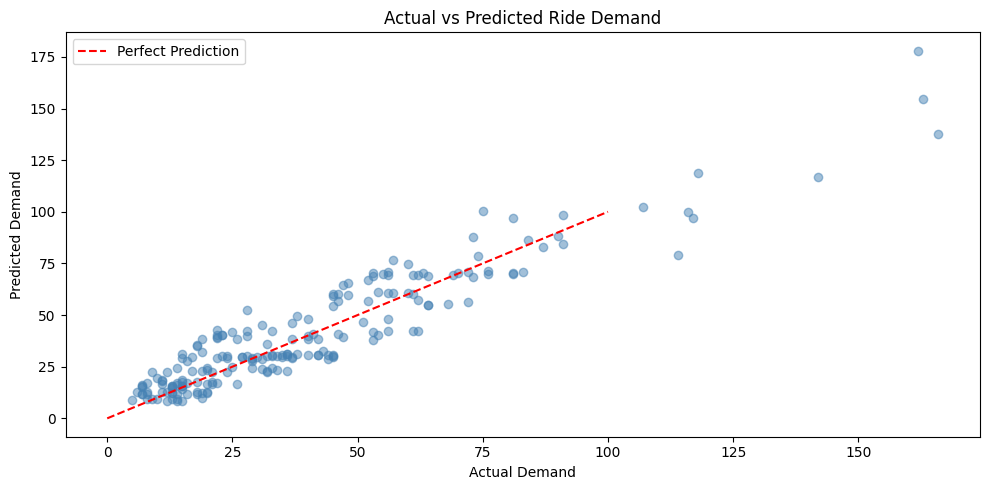

In [7]:
plt.figure(figsize=(10,5))
plt.scatter(y_test[:200], y_pred[:200], 
            alpha=0.5, color='steelblue')
plt.plot([0, 100], [0, 100], 
         color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Ride Demand')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.legend()
plt.tight_layout()
plt.show()

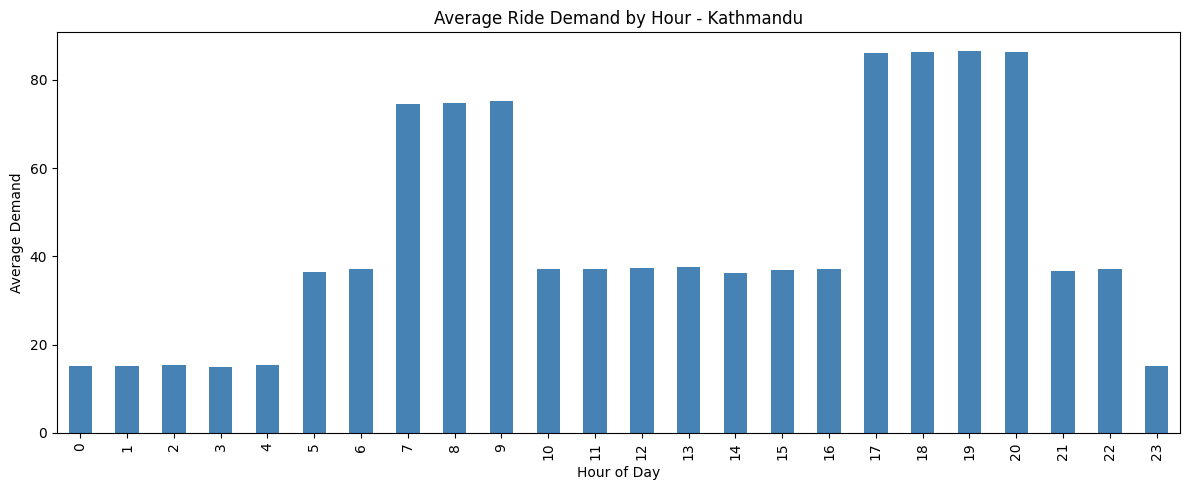

In [8]:
plt.figure(figsize=(12,5))
hourly = df.groupby('hour')['demand'].mean()
hourly.plot(kind='bar', color='steelblue')
plt.title('Average Ride Demand by Hour - Kathmandu')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.tight_layout()
plt.show()

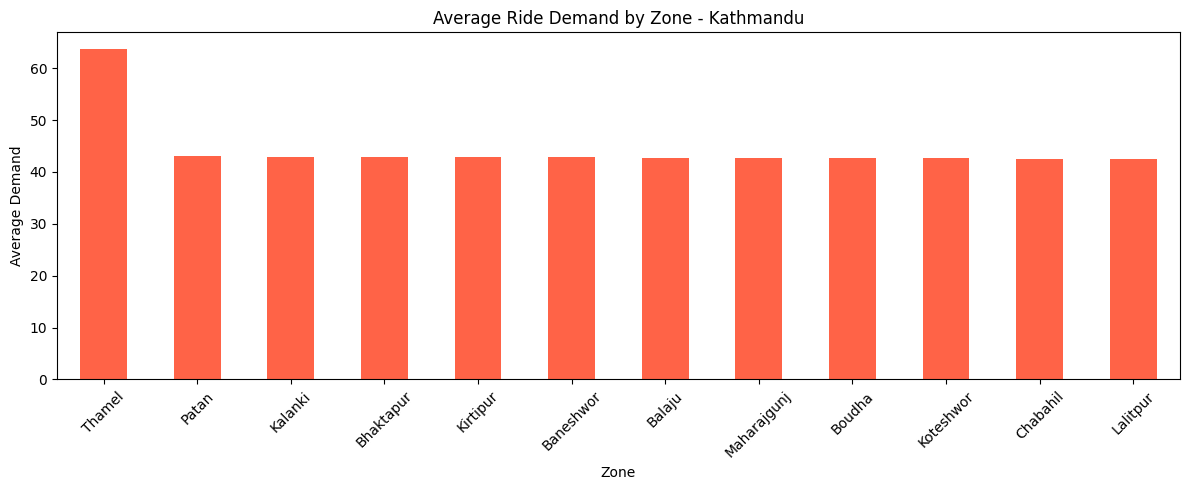

In [9]:
plt.figure(figsize=(12,5))
zone_demand = df.groupby('zone')['demand'].mean().sort_values(
    ascending=False)
zone_demand.plot(kind='bar', color='tomato')
plt.title('Average Ride Demand by Zone - Kathmandu')
plt.xlabel('Zone')
plt.ylabel('Average Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

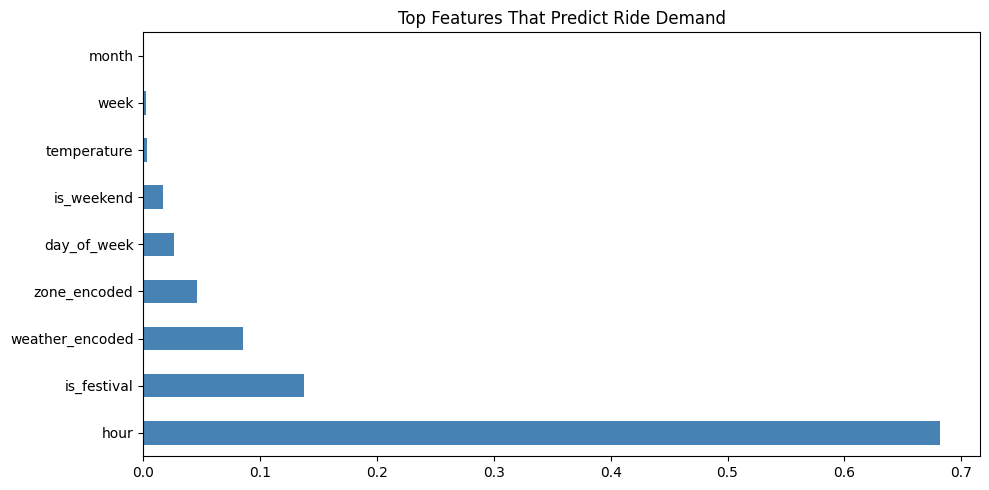

In [10]:
plt.figure(figsize=(10,5))
feat_imp = pd.Series(
    model.feature_importances_, index=features)
feat_imp.nlargest(9).plot(kind='barh', color='steelblue')
plt.title('Top Features That Predict Ride Demand')
plt.tight_layout()
plt.show()

In [11]:
pickle.dump(model, open(
    r'D:\projects\ride-demand-forecasting\demand_model.pkl','wb'))
pickle.dump(le_zone, open(
    r'D:\projects\ride-demand-forecasting\le_zone.pkl','wb'))
pickle.dump(le_weather, open(
    r'D:\projects\ride-demand-forecasting\le_weather.pkl','wb'))
pickle.dump(features, open(
    r'D:\projects\ride-demand-forecasting\features.pkl','wb'))

print("✅ All models saved!")

✅ All models saved!
